<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/huy/EDA_Ruou_Do.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân loại chất lượng rượu đỏ

##**1.Định nghĩa vấn đề**

## **2.Chuẩn bị vấn đề**

### **2.1.Khai báo thư viện**

In [15]:
import pandas as pd  #for data manipulation operations
import numpy as np  #for numeric operations on data
import seaborn as sns  #for data visualization operations
import matplotlib.pyplot as plt  #for data visualization operations
from sklearn.preprocessing import LabelEncoder # for encoding
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler #for standardization
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import scipy.stats as st
from termcolor import colored
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn import model_selection
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
#!pip install lightgbm
from lightgbm import LGBMClassifier
#ignore warnings
import warnings
warnings.filterwarnings("ignore")
#see model parametres
from sklearn import set_config
set_config(print_changed_only = False)

print(colored("\n THE REQUIRED LIBRARIES WERE SUCCESFULLY IMPORTED...", "green"))


 THE REQUIRED LIBRARIES WERE SUCCESFULLY IMPORTED...


### **2.2.Nạp dữ liệu**

In [18]:
#load data
redwine = pd.read_csv('winequality-red.csv', delimiter=';')

## **3.Mô tả thống kê**

#### **3.1. Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

#### **3.2. Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

#### **3.3. Kiểm tra tính toàn vẹn của dữ liệu**

## **4.EDA và trực quan hóa dữ liệu**

### **4.1.Phân tích đơn biến (Univariable Analysis)**

+ **Câu hỏi 1:** Chất lượng rượu trong tập dữ liệu được phân bổ như thế nào? Tỷ lệ giữa rượu có chất lượng cao, trung bình và thấp là bao nhiêu?

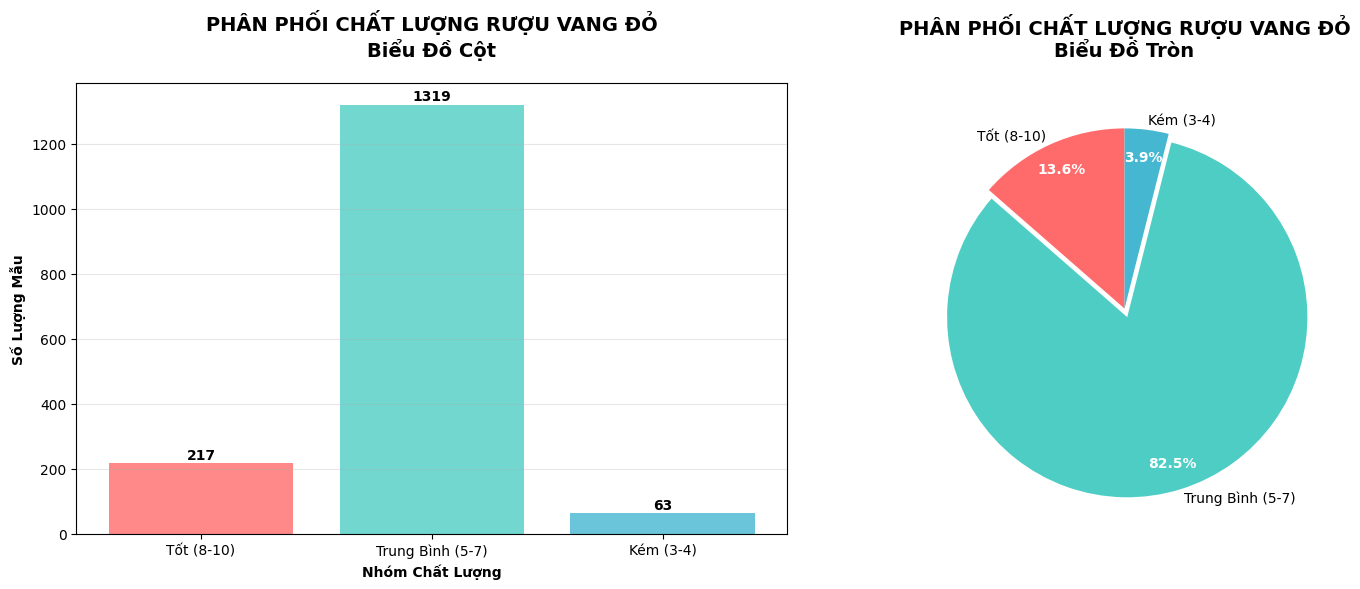

In [36]:
# 1. Phân loại chất lượng rượu
def classify_quality(score):
    if score >= 7:
        return 'Tốt (8-10)'
    elif score >= 5:
        return 'Trung Bình (5-7)'
    else:
        return 'Kém (3-4)'

redwine['quality_category'] = redwine['quality'].apply(classify_quality)
quality_counts = redwine['quality_category'].value_counts()

# Đảm bảo thứ tự các nhóm khi vẽ biểu đồ
category_order = ['Tốt (8-10)', 'Trung Bình (5-7)', 'Kém (3-4)']
quality_counts = quality_counts.reindex(category_order)

# 2. Tạo hình vẽ với 2 subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- BAR CHART ---
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
bars = ax1.bar(quality_counts.index, quality_counts.values, color=colors, alpha=0.8)
ax1.set_title('PHÂN PHỐI CHẤT LƯỢNG RƯỢU VANG ĐỎ\nBiểu Đồ Cột', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Nhóm Chất Lượng', fontweight='bold')
ax1.set_ylabel('Số Lượng Mẫu', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Thêm số liệu lên trên mỗi cột
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

# --- PIE CHART ---
wedges, texts, autotexts = ax2.pie(quality_counts.values,
                                   labels=quality_counts.index,
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   startangle=90,
                                   explode=(0, 0.05, 0),  # Tách nhãn Poor và Good ra một chút
                                   pctdistance=0.85,  # Đẩy phần trăm vào gần tâm hơn
                                   labeldistance=1.05)

ax2.set_title('PHÂN PHỐI CHẤT LƯỢNG RƯỢU VANG ĐỎ\nBiểu Đồ Tròn', fontsize=14, fontweight='bold', pad=20)

# Làm đẹp cho phần trăm trong pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.tight_layout()
plt.show()

 **Nhận xét:** Chất lượng rượu phân bổ không đồng đều, với đa số (82.5%) ở mức trung bình, tỷ lệ rượu ngon là 13.6% và rượu dở chỉ 4.0%. Điều này phản ánh thực tế là phần lớn rượu vang đỏ trên thị trường có chất lượng trung bình, trong khi rượu chất lượng cao thực sự khá hiếm và rượu chất lượng thấp rất ít.

+ **Câu hỏi 2:** Nồng độ cồn (alcohol) thường nằm trong khoảng nào? Phân phối của nó có gì đặc biệt không?

+ Câu hỏi 3: Độ axit dễ bay hơi (volatile acidity) - một yếu tố được cho là gây hỏng rượu - có phân bổ ra sao?

### **4.2.Phân tích đa biến (Multivariable Analysis)**

+ Câu hỏi 4: Liệu nồng độ cồn (alcohol) cao hơn có thực sự đi đôi với chất lượng (quality) cao hơn không?

+ Câu hỏi 5: Độ axit dễ bay hơi (volatile acidity) có phải là kẻ thù của chất lượng rượu không? Mối quan hệ của nó với quality là nghịch biến đúng không?


+ Câu hỏi 6: Nồng độ sulphates (sulphates) - một chất bảo quản - ảnh hưởng tới chất lượng (quality) như thế nào?

+ Câu hỏi 7: Các loại axit khác nhau có liên quan đến nhau không? Cụ thể là giữa fixed acidity và citric acid?

+ Câu hỏi 8: Tổng kết lại, những yếu tố nào có tương quan mạnh nhất (cả thuận và nghịch) với quality? Có cặp yếu tố nào bị trùng lặp thông tin (tương quan cao với nhau) không?

## **5. Kết luận**

# **Kết thúc**